In [1]:
import csv
from datetime import datetime
import numpy as np
import trompy as tp

def get_FEDevents(filename, eventname):
    formats = ['%Y-%m-%d %H:%M:%S', '%m/%d/%Y %H:%M:%S']
    
    try:
        file = open(filename)
    except FileNotFoundError:
        print(f"File not found: {filename}")
        return []
    
    csvreader = csv.reader(file)
    next(csvreader)  # Skip header
    rows = []
    for row in csvreader:
        rows.append(row)

    # Check if rows are empty
    if len(rows) == 0:
        print(f"No data found in file: {filename}")
        return []

    # Determine which format should be used
    try:
        tmp_date_time_obj = datetime.strptime(rows[0][0], formats[0])
        date_format = formats[0]
    except ValueError:
        tmp_date_time_obj = datetime.strptime(rows[0][0], formats[1])
        date_format = formats[1]

    timestamps = []
    for row in rows: 
        if row[7] == eventname:  # Check event column
            date_time_obj = datetime.strptime(row[0], date_format)
            timestamps.append(date_time_obj)

    if len(timestamps) == 0:
        print(f"No {eventname} events found in file: {filename}")
        return []

    t0 = rows[0][0]
    day = t0.split()[0] 
    lightson = day + " 07:00:00"
    refpoint = datetime.strptime(lightson, date_format)
    
    pellettimes = []
    for t in timestamps:
        Deltat = t - refpoint
        Deltatinseconds = Deltat.total_seconds()
        Deltatinhours = Deltatinseconds / 3600
        pellettimes.append(Deltatinhours)

    return pellettimes

def get_data_subset(dictionary, selectors, verbose=True):
    output_dictionary = dictionary.copy()
    for key, value in selectors.items():
        for mouse_id in dictionary.keys():
            try:
                if output_dictionary[mouse_id][key] != value:
                    output_dictionary.pop(mouse_id)
            except KeyError: 
                pass

    if verbose:
        print("{} items in output dictionary".format(len(output_dictionary.keys())))
    
    return output_dictionary

def get_data_fields(dictionary, fields, selectors):
    output_list = []
    reduced_dictionary = get_data_subset(dictionary, selectors)
    
    if len(reduced_dictionary.keys()) > 0:
        for field in fields:
            output_sublist = []
            try:
                for key in reduced_dictionary.keys():
                    output_sublist.append(reduced_dictionary[key][field])
            except KeyError:
                print("{} is not a key in selected dictionary".format(field))
                return
            output_list.append(output_sublist)
    else:
        print("No data in fields in selected dictionary")

    if len(output_list) == 1:
        output_list = output_list[0]
        
    return output_list
# Function to get meal, snack, and mega meal metrics, including mega_meal_frequency and mega_meal_size
def get_meal_and_snack_metrics(pellettimes, meal_threshold=1/60):
    if not pellettimes:
        return (0, 0, 0, 0, 0, 0, 0, 0, [[0]*24]*7, [[0]*24]*7, [[0]*24]*7, 0, 0, 0, 0)

    IPIs = np.diff(np.array(pellettimes))
    meals = []
    snacks = []
    mega_meals = []
    current_event = [pellettimes[0]]

    # Hourly tracking for each day
    hourly_meals_per_day = [[0]*24 for _ in range(7)]
    hourly_snacks_per_day = [[0]*24 for _ in range(7)]
    hourly_mega_meals_per_day = [[0]*24 for _ in range(7)]

    for i, ipi in enumerate(IPIs):
        if ipi <= meal_threshold:
            current_event.append(pellettimes[i + 1])
        else:
            if len(current_event) == 1:
                snacks.append(current_event)
                day_index = int(current_event[0] // 24)
                hour = int(current_event[0]) % 24
                if day_index < 7:  # Make sure we are within the 7-day boundary
                    hourly_snacks_per_day[day_index][hour] += 1
            elif 2 <= len(current_event) <= 5:
                meals.append(current_event)
                day_index = int(current_event[0] // 24)
                hour = int(current_event[0]) % 24
                if day_index < 7:
                    hourly_meals_per_day[day_index][hour] += 1
            elif len(current_event) >= 6:
                mega_meals.append(current_event)
                day_index = int(current_event[0] // 24)
                hour = int(current_event[0]) % 24
                if day_index < 7:
                    hourly_mega_meals_per_day[day_index][hour] += 1
            current_event = [pellettimes[i + 1]]

    # Handle the last sequence
    if current_event:
        day_index = int(current_event[0] // 24)
        hour = int(current_event[0]) % 24
        if len(current_event) == 1:
            snacks.append(current_event)
            if day_index < 7:
                hourly_snacks_per_day[day_index][hour] += 1
        elif 2 <= len(current_event) <= 4:
            meals.append(current_event)
            if day_index < 7:
                hourly_meals_per_day[day_index][hour] += 1
        elif len(current_event) >= 5:
            mega_meals.append(current_event)
            if day_index < 7:
                hourly_mega_meals_per_day[day_index][hour] += 1

    nmeals = len(meals)
    nsnacks = len(snacks)
    n_mega_meals = len(mega_meals)  # Add the number of mega meals

    total_pellets = len(pellettimes)
    mealsize = sum(len(meal) for meal in meals) / nmeals if nmeals else 0
    snack_size = sum(len(snack) for snack in snacks) / nsnacks if nsnacks else 0
    total_observation_period = max(pellettimes) - min(pellettimes)
    meal_frequency = nmeals / total_observation_period if total_observation_period > 0 else 0
    snack_frequency = nsnacks / total_observation_period if total_observation_period > 0 else 0
    mega_meal_frequency = n_mega_meals / total_observation_period if total_observation_period > 0 else 0
    average_mega_meal_size = sum(len(meal) for meal in mega_meals) / n_mega_meals if n_mega_meals else 0

    return (mealsize, snack_size, nmeals, meal_frequency, nsnacks, snack_frequency, 
            mega_meal_frequency, average_mega_meal_size, hourly_meals_per_day, 
            hourly_snacks_per_day, hourly_mega_meals_per_day, meals, snacks, mega_meals, n_mega_meals)


# Function to get events (meals, snacks, mega meals) per day based on timestamps
def get_events_per_day(events, days=7):
    events_per_day = [0] * days  # Initialize with zeros for the duration of the phase
    for event_list in events:
        if len(event_list) > 0:
            event_day = int(event_list[0] // 24)
            if event_day < days:
                events_per_day[event_day] += 1
    return events_per_day

# Function to calculate pellets per day
def get_pellets_per_day(timestamps, days=7):
    pellets_per_day = [0] * days
    for day in range(days):
        pellets = [t for t in timestamps if (t > day * 24) and (t < (day + 1) * 24)]
        n_pellets = len(pellets)
        pellets_per_day[day] = n_pellets

    return pellets_per_day


# Function to calculate inter-pellet intervals (IPI)
def get_interpellet_intervals(pellettimes):
    IPIs = np.diff(pellettimes)
    return IPIs

# Function to calculate intermeal intervals (IMI)
def get_intermeal_interval(pellettimes, meal_threshold=1/60):
    IPIs = np.diff(pellettimes)
    IMIs = [x for x in IPIs if x > meal_threshold]
    average_IMI = np.mean(IMIs) if IMIs else 0  # Handle case with no IMIs
    return average_IMI

# Load the metafile and process the data
metafile = "..\\FEDProtein_METAFILE.xls"
rows, header = tp.metafilereader(metafile, sheetname="METAFILE")

mice = {}
for row in rows:
    mouse_id = row[1]
    if mouse_id not in mice.keys():
        mice[mouse_id] = {}
        mice[mouse_id]["sex"] = row[4]
        mice[mouse_id]["order"] = row[5]

for key in mice.keys():
    for row in rows:
        if row[1] == key and row[3] == "FF":
            filename = "..\\data\\{}".format(row[0])
            if row[2] == "GRAIN":
                mice[key]["grain_timestamps"] = get_FEDevents(filename, "Pellet")
            elif row[2] == "PR":
                mice[key]["pr_timestamps"] = get_FEDevents(filename, "Pellet")
            elif row[2] == "NR":
                mice[key]["nr_timestamps"] = get_FEDevents(filename, "Pellet")
            else:
                print(row[2], "is not a valid type of pellet for", key)

# Add meal, snack, mega meal metrics, and IMI, IPI calculations to the dictionary
for key in mice.keys():
    grain_timestamps = mice[key].get("grain_timestamps", [])
    pr_timestamps = mice[key].get("pr_timestamps", [])
    nr_timestamps = mice[key].get("nr_timestamps", [])

    # Get metrics for GRAIN, PR, and NR phases
    grain_metrics = get_meal_and_snack_metrics(grain_timestamps)
    pr_metrics = get_meal_and_snack_metrics(pr_timestamps)
    nr_metrics = get_meal_and_snack_metrics(nr_timestamps)

    # GRAIN phase
    (
        mice[key]["grain_meal_size"],
        mice[key]["grain_snack_size"],
        mice[key]["grain_number_of_meals"],
        mice[key]["grain_meal_frequency"],
        mice[key]["grain_number_of_snacks"],
        mice[key]["grain_snack_frequency"],
        mice[key]["grain_mega_meal_frequency"],
        mice[key]["grain_mega_meal_size"],
        mice[key]["grain_hourly_meals"],
        mice[key]["grain_hourly_snacks"],
        mice[key]["grain_hourly_mega_meals"],
        grain_meals,
        grain_snacks,
        grain_mega_meals,
        mice[key]["grain_number_of_mega_meals"]  # Store the number of mega meals
    ) = grain_metrics

    # PR phase
    (
        mice[key]["pr_meal_size"],
        mice[key]["pr_snack_size"],
        mice[key]["pr_number_of_meals"],
        mice[key]["pr_meal_frequency"],
        mice[key]["pr_number_of_snacks"],
        mice[key]["pr_snack_frequency"],
        mice[key]["pr_mega_meal_frequency"],
        mice[key]["pr_mega_meal_size"],
        mice[key]["pr_hourly_meals"],
        mice[key]["pr_hourly_snacks"],
        mice[key]["pr_hourly_mega_meals"],
        pr_meals,
        pr_snacks,
        pr_mega_meals,
        mice[key]["pr_number_of_mega_meals"]  # Store the number of mega meals
    ) = pr_metrics

    # NR phase
    (
        mice[key]["nr_meal_size"],
        mice[key]["nr_snack_size"],
        mice[key]["nr_number_of_meals"],
        mice[key]["nr_meal_frequency"],
        mice[key]["nr_number_of_snacks"],
        mice[key]["nr_snack_frequency"],
        mice[key]["nr_mega_meal_frequency"],
        mice[key]["nr_mega_meal_size"],
        mice[key]["nr_hourly_meals"],
        mice[key]["nr_hourly_snacks"],
        mice[key]["nr_hourly_mega_meals"],
        nr_meals,
        nr_snacks,
        nr_mega_meals,
        mice[key]["nr_number_of_mega_meals"]  # Store the number of mega meals
    ) = nr_metrics

    # Events per day and pellets per day (as previously done)
    mice[key]["grain_meals_per_day"] = get_events_per_day(grain_meals, days=3)
    mice[key]["pr_meals_per_day"] = get_events_per_day(pr_meals, days=7)
    mice[key]["nr_meals_per_day"] = get_events_per_day(nr_meals, days=7)

    mice[key]["grain_snacks_per_day"] = get_events_per_day(grain_snacks, days=3)
    mice[key]["pr_snacks_per_day"] = get_events_per_day(pr_snacks, days=7)
    mice[key]["nr_snacks_per_day"] = get_events_per_day(nr_snacks, days=7)

    mice[key]["grain_mega_meals_per_day"] = get_events_per_day(grain_mega_meals, days=3)
    mice[key]["pr_mega_meals_per_day"] = get_events_per_day(pr_mega_meals, days=7)
    mice[key]["nr_mega_meals_per_day"] = get_events_per_day(nr_mega_meals, days=7)

    mice[key]["grain_pellets_per_day"] = get_pellets_per_day(mice[key]["grain_timestamps"], days=3)
    mice[key]["pr_pellets_per_day"] = get_pellets_per_day(mice[key]["pr_timestamps"], days=7)
    mice[key]["nr_pellets_per_day"] = get_pellets_per_day(mice[key]["nr_timestamps"], days=7)


# Now combine events and pellets per day for the entire 17-day time course (as before)
for key in mice.keys():
    # Combine pellets per day
    mice[key]["all_pellets_per_day"] = (
        mice[key].get("grain_pellets_per_day", [0] * 3) +
        mice[key].get("pr_pellets_per_day", [0] * 7) +
        mice[key].get("nr_pellets_per_day", [0] * 7)
    )

    # Combine meals per day
    mice[key]["all_meals_per_day"] = (
        mice[key].get("grain_meals_per_day", [0] * 3) +
        mice[key].get("pr_meals_per_day", [0] * 7) +
        mice[key].get("nr_meals_per_day", [0] * 7)
    )

    # Combine snacks per day
    mice[key]["all_snacks_per_day"] = (
        mice[key].get("grain_snacks_per_day", [0] * 3) +
        mice[key].get("pr_snacks_per_day", [0] * 7) +
        mice[key].get("nr_snacks_per_day", [0] * 7)
    )

    # Combine mega meals per day
    mice[key]["all_mega_meals_per_day"] = (
        mice[key].get("grain_mega_meals_per_day", [0] * 3) +
        mice[key].get("pr_mega_meals_per_day", [0] * 7) +
        mice[key].get("nr_mega_meals_per_day", [0] * 7)
    )

# Output the results to check the data structure
for key, value in mice.items():
    print(f"Mouse {key}:")
    print("  Pellets per day:", mice[key]["all_pellets_per_day"])
    print("  Meals per day:", mice[key]["all_meals_per_day"])
    print("  Snacks per day:", mice[key]["all_snacks_per_day"])
    print("  Mega Meals per hour:", mice[key]["nr_hourly_mega_meals"])
    print("  Mega Meals Frequency:", mice[key]["nr_mega_meal_frequency"])
    print("  Mega Meals Size:", mice[key]["nr_mega_meal_size"])

Mouse FEDXA01:
  Pellets per day: [340, 271, 224, 161, 155, 176, 184, 215, 231, 240, 246, 234, 222, 211, 241, 223, 219]
  Meals per day: [47, 30, 28, 37, 33, 36, 27, 30, 34, 25, 14, 24, 24, 21, 20, 11, 11]
  Snacks per day: [30, 18, 25, 32, 44, 52, 62, 28, 25, 13, 13, 14, 14, 19, 18, 12, 13]
  Mega Meals per hour: [[0, 0, 0, 2, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 2, 3, 2, 1, 0, 0, 1, 1, 1], [0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 2, 2, 2, 1, 2, 0, 0, 0], [0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 1], [0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 2, 2, 0, 1, 1, 1, 0], [1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 2, 2, 3, 1, 0, 1, 0, 0, 1], [1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 2, 2, 1, 1, 1, 2, 1, 0, 2], [1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 2, 2, 2, 1, 1, 1, 1, 1, 2]]
  Mega Meals Frequency: 0.7914710335259267
  Mega Meals Size: 7.916666666666667
Mouse FEDXA02:
  Pellets per day: [304, 214, 194, 154, 153, 204, 211, 203, 226, 214, 

In [2]:
# Selectors for grouping mice data
nrpr_male_selector = {"order": 1, "sex": "M"}
prnr_male_selector = {"order": 2, "sex": "M"}
nrpr_female_selector = {"order": 1, "sex": "F"}
prnr_female_selector = {"order": 2, "sex": "F"}


11 items in output dictionary
12 items in output dictionary


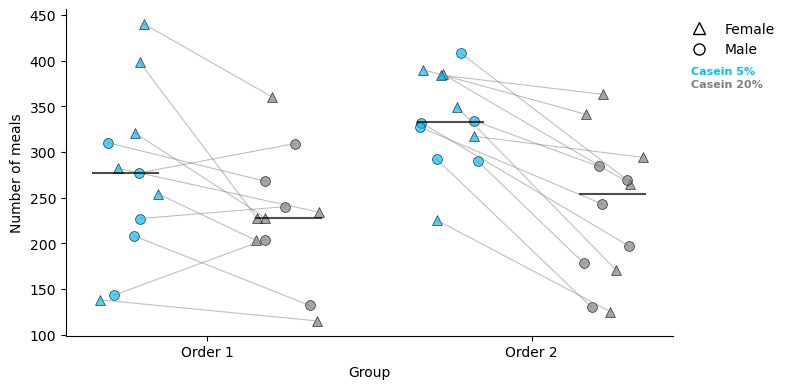

In [66]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# Extract combined meal data for PR and NR phases, separated by order
nrpr_meals = get_data_fields(mice, ["pr_number_of_meals", "nr_number_of_meals"], {"order": 1})
prnr_meals = get_data_fields(mice, ["pr_number_of_meals", "nr_number_of_meals"], {"order": 2})

# Prepare data for plotting
data = [nrpr_meals[0], nrpr_meals[1], prnr_meals[0], prnr_meals[1]]
group_labels = ["Order 1 (PR)", "Order 1 (NR)", "Order 2 (PR)", "Order 2 (NR)"]
colors = {"PR": "deepskyblue", "NR": "grey"}
offset = {"PR": -0.05, "NR": 0.05}  # Reduced offset for compact spacing
group_positions = {"Order 1": 0, "Order 2": 0.2}  # Closer positions for minimal gap

# Create a figure and axis
fig, ax = plt.subplots(figsize=(8, 4))
jitter_strength = 0.02

# Plot data points and connect pairs with lines
for i, label in enumerate(["Order 1", "Order 2"]):
    pr_data = data[i * 2]   # PR data for Order 1 or Order 2
    nr_data = data[i * 2 + 1]  # NR data for Order 1 or Order 2

    for j in range(len(pr_data)):
        # Apply jitter to x-positions for PR and NR
        pr_x = group_positions[label] + offset["PR"] + np.random.uniform(-jitter_strength, jitter_strength)
        nr_x = group_positions[label] + offset["NR"] + np.random.uniform(-jitter_strength, jitter_strength)
        
        # Draw line connecting PR and NR for each individual mouse
        ax.plot([pr_x, nr_x], [pr_data[j], nr_data[j]], color='gray', linestyle='-', linewidth=0.8, alpha=0.5)

        # Plot individual data points with gender-specific markers
        marker = '^' if j % 2 == 0 else 'o'  # Triangles for females, circles for males
        sns.scatterplot(x=[pr_x], y=[pr_data[j]], color=colors["PR"], marker=marker, s=50, alpha=0.7, edgecolor="black")
        sns.scatterplot(x=[nr_x], y=[nr_data[j]], color=colors["NR"], marker=marker, s=50, alpha=0.7, edgecolor="black")

# Add median lines for each group and diet
for group, pos in group_positions.items():
    for diet, diet_color in colors.items():
        relevant_data = data[group_labels.index(f"{group} ({diet})")]
        median_value = np.median(relevant_data)
        x_val = pos + offset[diet]
        ax.plot([x_val - 0.02, x_val + 0.02], [median_value, median_value], color='k', linewidth=1.5, alpha=0.7)

# Customize legend with gender markers and colored text for PR and NR
custom_lines = [
    Line2D([0], [0], marker='^', color='black', linestyle='', markersize=8, label='Female', fillstyle='none'),
    Line2D([0], [0], marker='o', color='black', linestyle='', markersize=8, label='Male', fillstyle='none')
]
plt.legend(handles=custom_lines, loc="upper left", bbox_to_anchor=(1, 1), frameon=False)

# Add combined colored text for PR and NR next to the legend
plt.text(1.03, 0.8, 'Casein 5%', color='deepskyblue', transform=ax.transAxes, fontsize=8, fontweight='bold')
plt.text(1.03, 0.76, 'Casein 20%', color='grey', transform=ax.transAxes, fontsize=8, fontweight='bold')

# Plot settings
plt.xticks([group_positions["Order 1"], group_positions["Order 2"]],
           ["Order 1", "Order 2"], fontsize=10)
plt.xlabel("Group")
plt.ylabel("Number of meals")
sns.despine()
plt.tight_layout()
plt.show()

# Save the figure if needed
# fig.savefig("connected_meals_scatter_plot.pdf")


11 items in output dictionary
12 items in output dictionary


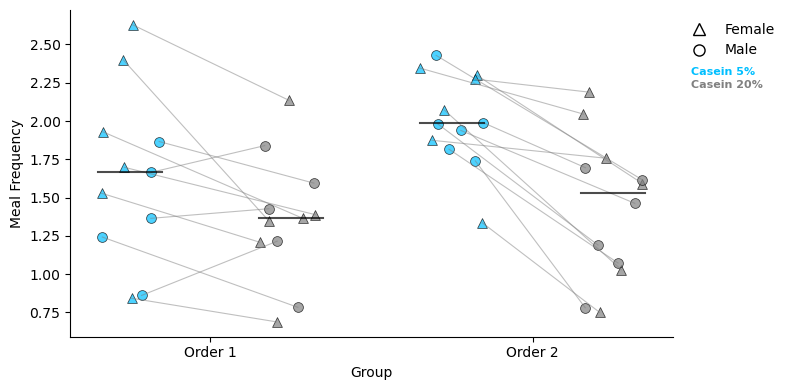

In [65]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# Extract combined meal frequency data for PR and NR phases, separated by order
nrpr_frequency = get_data_fields(mice, ["pr_meal_frequency", "nr_meal_frequency"], {"order": 1})
prnr_frequency = get_data_fields(mice, ["pr_meal_frequency", "nr_meal_frequency"], {"order": 2})

# Prepare data for plotting
data = [nrpr_frequency[0], nrpr_frequency[1], prnr_frequency[0], prnr_frequency[1]]
group_labels = ["Order 1 (PR)", "Order 1 (NR)", "Order 2 (PR)", "Order 2 (NR)"]
colors = {"PR": "deepskyblue", "NR": "grey"}
offset = {"PR": -0.05, "NR": 0.05}  # Offset for compact spacing
group_positions = {"Order 1": 0, "Order 2": 0.2}  # Positions for minimal gap between groups

# Create a figure and axis
fig, ax = plt.subplots(figsize=(8, 4))
jitter_strength = 0.02

# Plot data points and lines between PR and NR data
for i, label in enumerate(["Order 1", "Order 2"]):
    pr_data = data[i * 2]   # PR data for Order 1 or Order 2
    nr_data = data[i * 2 + 1]  # NR data for Order 1 or Order 2

    for j in range(len(pr_data)):
        # Apply jitter to x-positions
        pr_x = group_positions[label] + offset["PR"] + np.random.uniform(-jitter_strength, jitter_strength)
        nr_x = group_positions[label] + offset["NR"] + np.random.uniform(-jitter_strength, jitter_strength)
        
        # Plot line connecting PR and NR for each individual mouse
        ax.plot([pr_x, nr_x], [pr_data[j], nr_data[j]], color='gray', linestyle='-', linewidth=0.8, alpha=0.5)

        # Plot data points with gender-specific markers
        marker = '^' if j % 2 == 0 else 'o'  # Triangles for females, circles for males
        sns.scatterplot(x=[pr_x], y=[pr_data[j]], color=colors["PR"], marker=marker, s=50, alpha=0.7, edgecolor="black")
        sns.scatterplot(x=[nr_x], y=[nr_data[j]], color=colors["NR"], marker=marker, s=50, alpha=0.7, edgecolor="black")

# Add median lines for each group and diet
for group, pos in group_positions.items():
    for diet, diet_color in colors.items():
        relevant_data = data[group_labels.index(f"{group} ({diet})")]
        median_value = np.median(relevant_data)
        x_val = pos + offset[diet]
        ax.plot([x_val - 0.02, x_val + 0.02], [median_value, median_value], color='k', linewidth=1.5, alpha=0.7)

# Customize legend with no frame and no title
custom_lines = [
    Line2D([0], [0], marker='^', color='black', linestyle='', markersize=8, label='Female', fillstyle='none'),
    Line2D([0], [0], marker='o', color='black', linestyle='', markersize=8, label='Male', fillstyle='none')
]
plt.legend(handles=custom_lines, loc="upper left", bbox_to_anchor=(1, 1), frameon=False)

# Add combined colored text for PR and NR next to the legend
plt.text(1.03, 0.8, 'Casein 5%', color='deepskyblue', transform=ax.transAxes, fontsize=8, fontweight='bold')
plt.text(1.03, 0.76, 'Casein 20%', color='grey', transform=ax.transAxes, fontsize=8, fontweight='bold')

# Plot settings
plt.xticks([group_positions["Order 1"], group_positions["Order 2"]],
           ["Order 1", "Order 2"], fontsize=10)
plt.xlabel("Group")
plt.ylabel("Meal Frequency")
sns.despine()
plt.tight_layout()
plt.show()

# Save the figure if needed
# fig.savefig("connected_meal_frequency_scatter_plot.pdf")


11 items in output dictionary
12 items in output dictionary


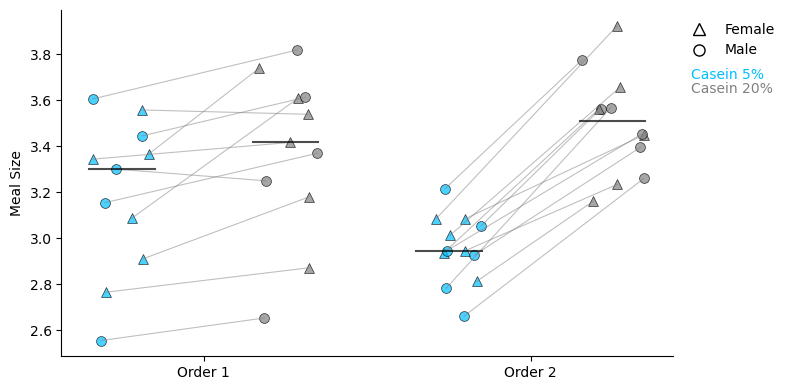

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Extract combined meal size data for PR and NR phases, separated by order
nrpr_size = get_data_fields(mice, ["pr_meal_size", "nr_meal_size"], {"order": 1})
prnr_size = get_data_fields(mice, ["pr_meal_size", "nr_meal_size"], {"order": 2})

# Prepare data for plotting
data = [nrpr_size[0], nrpr_size[1], prnr_size[0], prnr_size[1]]
group_labels = ["Order 1 (PR)", "Order 1 (NR)", "Order 2 (PR)", "Order 2 (NR)"]
colors = {"PR": "deepskyblue", "NR": "grey"}
offset = {"PR": -0.05, "NR": 0.05}  # Offset for compact spacing
group_positions = {"Order 1": 0, "Order 2": 0.2}  # Closer positions for minimal gap

# Create a figure and axis
fig, ax = plt.subplots(figsize=(8, 4))
jitter_strength = 0.02

# Plot data points and connect pairs with lines
for i, label in enumerate(["Order 1", "Order 2"]):
    pr_data = data[i * 2]   # PR data for Order 1 or Order 2
    nr_data = data[i * 2 + 1]  # NR data for Order 1 or Order 2

    for j in range(len(pr_data)):
        # Apply jitter to x-positions for PR and NR
        pr_x = group_positions[label] + offset["PR"] + np.random.uniform(-jitter_strength, jitter_strength)
        nr_x = group_positions[label] + offset["NR"] + np.random.uniform(-jitter_strength, jitter_strength)
        
        # Draw line connecting PR and NR for each individual mouse
        ax.plot([pr_x, nr_x], [pr_data[j], nr_data[j]], color='gray', linestyle='-', linewidth=0.8, alpha=0.5)

        # Plot individual data points with gender-specific markers
        marker = '^' if j % 2 == 0 else 'o'  # Triangles for females, circles for males
        sns.scatterplot(x=[pr_x], y=[pr_data[j]], color=colors["PR"], marker=marker, s=50, alpha=0.7, edgecolor="black")
        sns.scatterplot(x=[nr_x], y=[nr_data[j]], color=colors["NR"], marker=marker, s=50, alpha=0.7, edgecolor="black")

# Add median lines for each group and diet
for group, pos in group_positions.items():
    for diet, diet_color in colors.items():
        relevant_data = data[group_labels.index(f"{group} ({diet})")]
        median_value = np.median(relevant_data)
        x_val = pos + offset[diet]
        ax.plot([x_val - 0.02, x_val + 0.02], [median_value, median_value], color='k', linewidth=1.5, alpha=0.7)

# Customize legend with no frame and no title
custom_lines = [
    Line2D([0], [0], marker='^', color='black', linestyle='', markersize=8, label='Female', fillstyle='none'),
    Line2D([0], [0], marker='o', color='black', linestyle='', markersize=8, label='Male', fillstyle='none')
]
plt.legend(handles=custom_lines, loc="upper left", bbox_to_anchor=(1, 1), frameon=False)


# Add combined colored text for PR and NR next to the legend
plt.text(1.03, 0.8, 'Casein 5%', color='deepskyblue', transform=ax.transAxes, fontsize=10)
plt.text(1.03, 0.76, 'Casein 20%', color='grey', transform=ax.transAxes, fontsize=10)





# Plot settings
plt.xticks([group_positions["Order 1"], group_positions["Order 2"]],
           ["Order 1", "Order 2"], fontsize=10)
plt.xlabel("")
plt.ylabel("Meal Size")
sns.despine()
plt.tight_layout()
plt.show()

# Save the figure if needed
# fig.savefig("connected_meal_size_scatter_plot.pdf")


11 items in output dictionary
12 items in output dictionary


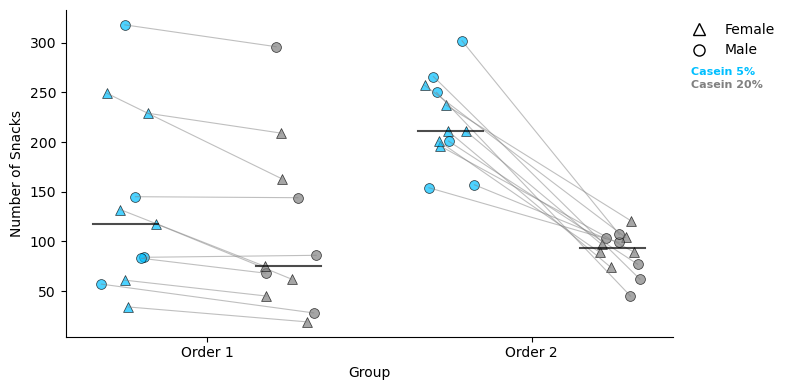

In [68]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Extract combined snack count data for PR and NR phases, separated by order
nrpr_snacks = get_data_fields(mice, ["pr_number_of_snacks", "nr_number_of_snacks"], {"order": 1})
prnr_snacks = get_data_fields(mice, ["pr_number_of_snacks", "nr_number_of_snacks"], {"order": 2})

# Prepare data for plotting
data = [nrpr_snacks[0], nrpr_snacks[1], prnr_snacks[0], prnr_snacks[1]]
group_labels = ["Order 1 (PR)", "Order 1 (NR)", "Order 2 (PR)", "Order 2 (NR)"]
colors = {"PR": "deepskyblue", "NR": "grey"}
offset = {"PR": -0.05, "NR": 0.05}  # Offset for compact spacing
group_positions = {"Order 1": 0, "Order 2": 0.2}  # Closer positions for minimal gap

# Create a figure and axis
fig, ax = plt.subplots(figsize=(8, 4))
jitter_strength = 0.02

# Plot data points and connect pairs with lines
for i, label in enumerate(["Order 1", "Order 2"]):
    pr_data = data[i * 2]   # PR data for Order 1 or Order 2
    nr_data = data[i * 2 + 1]  # NR data for Order 1 or Order 2

    for j in range(len(pr_data)):
        # Apply jitter to x-positions for PR and NR
        pr_x = group_positions[label] + offset["PR"] + np.random.uniform(-jitter_strength, jitter_strength)
        nr_x = group_positions[label] + offset["NR"] + np.random.uniform(-jitter_strength, jitter_strength)
        
        # Draw line connecting PR and NR for each individual mouse
        ax.plot([pr_x, nr_x], [pr_data[j], nr_data[j]], color='gray', linestyle='-', linewidth=0.8, alpha=0.5)

        # Plot individual data points with gender-specific markers
        marker = '^' if j % 2 == 0 else 'o'  # Triangles for females, circles for males
        sns.scatterplot(x=[pr_x], y=[pr_data[j]], color=colors["PR"], marker=marker, s=50, alpha=0.7, edgecolor="black")
        sns.scatterplot(x=[nr_x], y=[nr_data[j]], color=colors["NR"], marker=marker, s=50, alpha=0.7, edgecolor="black")

# Add median lines for each group and diet
for group, pos in group_positions.items():
    for diet, diet_color in colors.items():
        relevant_data = data[group_labels.index(f"{group} ({diet})")]
        median_value = np.median(relevant_data)
        x_val = pos + offset[diet]
        ax.plot([x_val - 0.02, x_val + 0.02], [median_value, median_value], color='k', linewidth=1.5, alpha=0.7)
# Customize legend with no frame and no title
custom_lines = [
    Line2D([0], [0], marker='^', color='black', linestyle='', markersize=8, label='Female', fillstyle='none'),
    Line2D([0], [0], marker='o', color='black', linestyle='', markersize=8, label='Male', fillstyle='none')
]
plt.legend(handles=custom_lines, loc="upper left", bbox_to_anchor=(1, 1), frameon=False)


# Add combined colored text for PR and NR next to the legend
plt.text(1.03, 0.8, 'Casein 5%', color='deepskyblue', transform=ax.transAxes, fontsize=8, fontweight='bold')
plt.text(1.03, 0.76, 'Casein 20%', color='grey', transform=ax.transAxes, fontsize=8, fontweight='bold')

# Plot settings
plt.xticks([group_positions["Order 1"], group_positions["Order 2"]],
           ["Order 1", "Order 2"], fontsize=10)
plt.xlabel("Group")
plt.ylabel("Number of Snacks")
sns.despine()
plt.tight_layout()
plt.show()

# Save the figure if needed
# fig.savefig("connected_snack_count_scatter_plot.pdf")


11 items in output dictionary
12 items in output dictionary


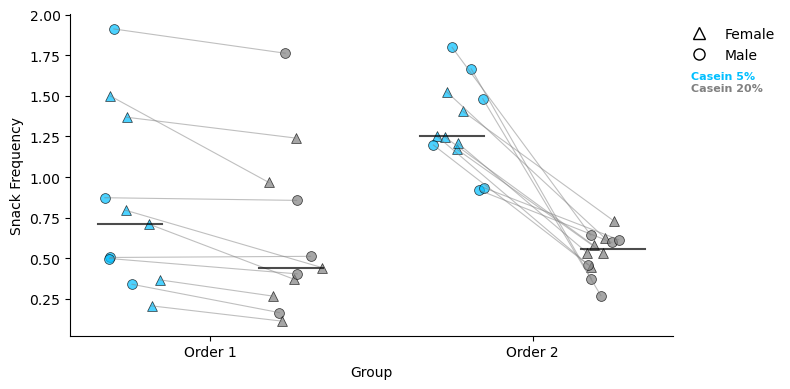

In [69]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Extract combined snack frequency data for PR and NR phases, separated by order
nrpr_snack_freq = get_data_fields(mice, ["pr_snack_frequency", "nr_snack_frequency"], {"order": 1})
prnr_snack_freq = get_data_fields(mice, ["pr_snack_frequency", "nr_snack_frequency"], {"order": 2})

# Prepare data for plotting
data = [nrpr_snack_freq[0], nrpr_snack_freq[1], prnr_snack_freq[0], prnr_snack_freq[1]]
group_labels = ["Order 1 (PR)", "Order 1 (NR)", "Order 2 (PR)", "Order 2 (NR)"]
colors = {"PR": "deepskyblue", "NR": "grey"}
offset = {"PR": -0.05, "NR": 0.05}  # Offset for compact spacing
group_positions = {"Order 1": 0, "Order 2": 0.2}  # Closer positions for minimal gap

# Create a figure and axis
fig, ax = plt.subplots(figsize=(8, 4))
jitter_strength = 0.02

# Plot data points and connect pairs with lines
for i, label in enumerate(["Order 1", "Order 2"]):
    pr_data = data[i * 2]   # PR data for Order 1 or Order 2
    nr_data = data[i * 2 + 1]  # NR data for Order 1 or Order 2

    for j in range(len(pr_data)):
        # Apply jitter to x-positions for PR and NR
        pr_x = group_positions[label] + offset["PR"] + np.random.uniform(-jitter_strength, jitter_strength)
        nr_x = group_positions[label] + offset["NR"] + np.random.uniform(-jitter_strength, jitter_strength)
        
        # Draw line connecting PR and NR for each individual mouse
        ax.plot([pr_x, nr_x], [pr_data[j], nr_data[j]], color='gray', linestyle='-', linewidth=0.8, alpha=0.5)

        # Plot individual data points with gender-specific markers
        marker = '^' if j % 2 == 0 else 'o'  # Triangles for females, circles for males
        sns.scatterplot(x=[pr_x], y=[pr_data[j]], color=colors["PR"], marker=marker, s=50, alpha=0.7, edgecolor="black")
        sns.scatterplot(x=[nr_x], y=[nr_data[j]], color=colors["NR"], marker=marker, s=50, alpha=0.7, edgecolor="black")

# Add median lines for each group and diet
for group, pos in group_positions.items():
    for diet, diet_color in colors.items():
        relevant_data = data[group_labels.index(f"{group} ({diet})")]
        median_value = np.median(relevant_data)
        x_val = pos + offset[diet]
        ax.plot([x_val - 0.02, x_val + 0.02], [median_value, median_value], color='k', linewidth=1.5, alpha=0.7)

# Customize legend with no frame and no title
custom_lines = [
    Line2D([0], [0], marker='^', color='black', linestyle='', markersize=8, label='Female', fillstyle='none'),
    Line2D([0], [0], marker='o', color='black', linestyle='', markersize=8, label='Male', fillstyle='none')
]
plt.legend(handles=custom_lines, loc="upper left", bbox_to_anchor=(1, 1), frameon=False)


# Add combined colored text for PR and NR next to the legend
plt.text(1.03, 0.8, 'Casein 5%', color='deepskyblue', transform=ax.transAxes, fontsize=8, fontweight='bold')
plt.text(1.03, 0.76, 'Casein 20%', color='grey', transform=ax.transAxes, fontsize=8, fontweight='bold')


# Plot settings
plt.xticks([group_positions["Order 1"], group_positions["Order 2"]],
           ["Order 1", "Order 2"], fontsize=10)
plt.xlabel("Group")
plt.ylabel("Snack Frequency")
sns.despine()
plt.tight_layout()
plt.show()

# Save the figure if needed
# fig.savefig("connected_snack_frequency_scatter_plot.pdf")


6 items in output dictionary
6 items in output dictionary
5 items in output dictionary
6 items in output dictionary


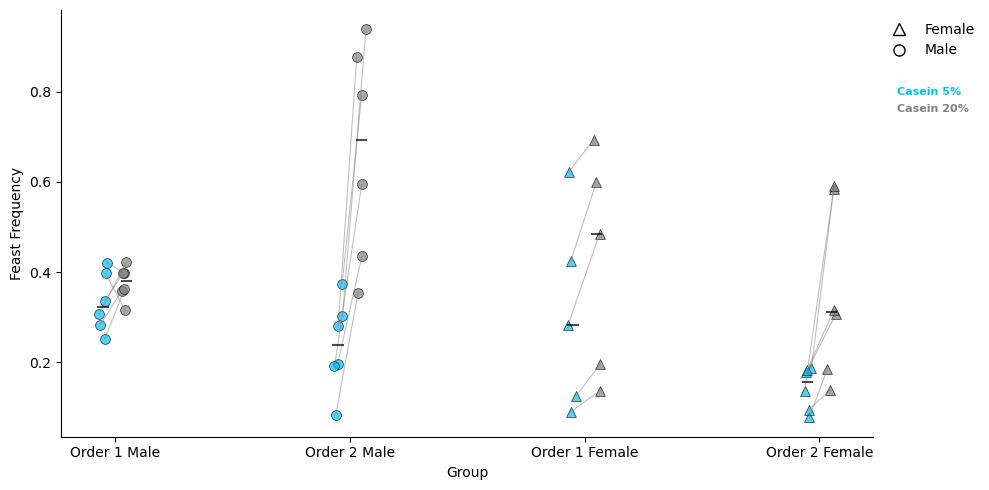

In [70]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Extract Feast frequency data for PR and NR phases, separated by order and sex
nrpr_male_feast_freq = get_data_fields(mice, ["pr_mega_meal_frequency", "nr_mega_meal_frequency"], {"order": 1, "sex": "M"})
prnr_male_feast_freq = get_data_fields(mice, ["pr_mega_meal_frequency", "nr_mega_meal_frequency"], {"order": 2, "sex": "M"})
nrpr_female_feast_freq = get_data_fields(mice, ["pr_mega_meal_frequency", "nr_mega_meal_frequency"], {"order": 1, "sex": "F"})
prnr_female_feast_freq = get_data_fields(mice, ["pr_mega_meal_frequency", "nr_mega_meal_frequency"], {"order": 2, "sex": "F"})

# Prepare data for plotting
data = [
    nrpr_male_feast_freq[0], nrpr_male_feast_freq[1], prnr_male_feast_freq[0], prnr_male_feast_freq[1],
    nrpr_female_feast_freq[0], nrpr_female_feast_freq[1], prnr_female_feast_freq[0], prnr_female_feast_freq[1]
]
group_labels = [
    "Order 1 Male (PR)", "Order 1 Male (NR)", "Order 2 Male (PR)", "Order 2 Male (NR)",
    "Order 1 Female (PR)", "Order 1 Female (NR)", "Order 2 Female (PR)", "Order 2 Female (NR)"
]
colors = {"PR": "deepskyblue", "NR": "grey"}
offset = {"PR": -0.05, "NR": 0.05}  # Offset for compact spacing
group_positions = {
    "Order 1 Male": 0, "Order 2 Male": 1,
    "Order 1 Female": 2, "Order 2 Female": 3
}

# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 5))
jitter_strength = 0.02

# Plot data points and connect pairs with lines
for i, label in enumerate(["Order 1 Male", "Order 2 Male", "Order 1 Female", "Order 2 Female"]):
    pr_data = data[i * 2]   # PR data for each group
    nr_data = data[i * 2 + 1]  # NR data for each group

    for j in range(len(pr_data)):
        # Apply jitter to x-positions for PR and NR
        pr_x = group_positions[label] + offset["PR"] + np.random.uniform(-jitter_strength, jitter_strength)
        nr_x = group_positions[label] + offset["NR"] + np.random.uniform(-jitter_strength, jitter_strength)
        
        # Draw line connecting PR and NR for each individual mouse
        ax.plot([pr_x, nr_x], [pr_data[j], nr_data[j]], color='gray', linestyle='-', linewidth=0.8, alpha=0.5)

        # Plot individual data points with gender-specific markers
        marker = '^' if 'Female' in label else 'o'  # Triangles for females, circles for males
        sns.scatterplot(x=[pr_x], y=[pr_data[j]], color=colors["PR"], marker=marker, s=50, alpha=0.7, edgecolor="black")
        sns.scatterplot(x=[nr_x], y=[nr_data[j]], color=colors["NR"], marker=marker, s=50, alpha=0.7, edgecolor="black")

# Add median lines for each group and diet
for group, pos in group_positions.items():
    for diet, diet_color in colors.items():
        relevant_data = data[group_labels.index(f"{group} ({diet})")]
        median_value = np.median(relevant_data)
        x_val = pos + offset[diet]
        ax.plot([x_val - 0.02, x_val + 0.02], [median_value, median_value], color='k', linewidth=1.5, alpha=0.7)

# Customize legend with no frame and no title
custom_lines = [
    Line2D([0], [0], marker='^', color='black', linestyle='', markersize=8, label='Female', fillstyle='none'),
    Line2D([0], [0], marker='o', color='black', linestyle='', markersize=8, label='Male', fillstyle='none')
]
plt.legend(handles=custom_lines, loc="upper left", bbox_to_anchor=(1, 1), frameon=False)


# Add combined colored text for PR and NR next to the legend
plt.text(1.03, 0.8, 'Casein 5%', color='deepskyblue', transform=ax.transAxes, fontsize=8, fontweight='bold')
plt.text(1.03, 0.76, 'Casein 20%', color='grey', transform=ax.transAxes, fontsize=8, fontweight='bold')

# Plot settings
plt.xticks([group_positions["Order 1 Male"], group_positions["Order 2 Male"],
            group_positions["Order 1 Female"], group_positions["Order 2 Female"]],
           ["Order 1 Male", "Order 2 Male", "Order 1 Female", "Order 2 Female"], fontsize=10)
plt.xlabel("Group")
plt.ylabel("Feast Frequency")
sns.despine()
plt.tight_layout()
plt.show()

# Save the figure if needed
# fig.savefig("feast_frequency_separated_by_sex.pdf")


6 items in output dictionary
6 items in output dictionary
5 items in output dictionary
6 items in output dictionary


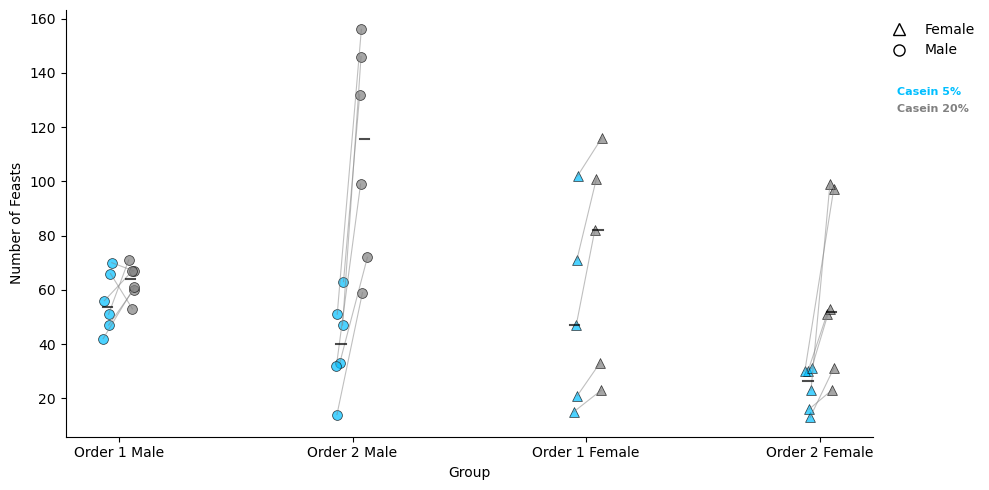

In [71]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Extract Feast frequency data for PR and NR phases, separated by order and sex
nrpr_male_feast_freq = get_data_fields(mice, ["pr_number_of_mega_meals", "nr_number_of_mega_meals"], {"order": 1, "sex": "M"})
prnr_male_feast_freq = get_data_fields(mice, ["pr_number_of_mega_meals", "nr_number_of_mega_meals"], {"order": 2, "sex": "M"})
nrpr_female_feast_freq = get_data_fields(mice, ["pr_number_of_mega_meals", "nr_number_of_mega_meals"], {"order": 1, "sex": "F"})
prnr_female_feast_freq = get_data_fields(mice, ["pr_number_of_mega_meals", "nr_number_of_mega_meals"], {"order": 2, "sex": "F"})

# Prepare data for plotting
data = [
    nrpr_male_feast_freq[0], nrpr_male_feast_freq[1], prnr_male_feast_freq[0], prnr_male_feast_freq[1],
    nrpr_female_feast_freq[0], nrpr_female_feast_freq[1], prnr_female_feast_freq[0], prnr_female_feast_freq[1]
]
group_labels = [
    "Order 1 Male (PR)", "Order 1 Male (NR)", "Order 2 Male (PR)", "Order 2 Male (NR)",
    "Order 1 Female (PR)", "Order 1 Female (NR)", "Order 2 Female (PR)", "Order 2 Female (NR)"
]
colors = {"PR": "deepskyblue", "NR": "grey"}
offset = {"PR": -0.05, "NR": 0.05}  # Offset for compact spacing
group_positions = {
    "Order 1 Male": 0, "Order 2 Male": 1,
    "Order 1 Female": 2, "Order 2 Female": 3
}

# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 5))
jitter_strength = 0.02

# Plot data points and connect pairs with lines
for i, label in enumerate(["Order 1 Male", "Order 2 Male", "Order 1 Female", "Order 2 Female"]):
    pr_data = data[i * 2]   # PR data for each group
    nr_data = data[i * 2 + 1]  # NR data for each group

    for j in range(len(pr_data)):
        # Apply jitter to x-positions for PR and NR
        pr_x = group_positions[label] + offset["PR"] + np.random.uniform(-jitter_strength, jitter_strength)
        nr_x = group_positions[label] + offset["NR"] + np.random.uniform(-jitter_strength, jitter_strength)
        
        # Draw line connecting PR and NR for each individual mouse
        ax.plot([pr_x, nr_x], [pr_data[j], nr_data[j]], color='gray', linestyle='-', linewidth=0.8, alpha=0.5)

        # Plot individual data points with gender-specific markers
        marker = '^' if 'Female' in label else 'o'  # Triangles for females, circles for males
        sns.scatterplot(x=[pr_x], y=[pr_data[j]], color=colors["PR"], marker=marker, s=50, alpha=0.7, edgecolor="black")
        sns.scatterplot(x=[nr_x], y=[nr_data[j]], color=colors["NR"], marker=marker, s=50, alpha=0.7, edgecolor="black")

# Add median lines for each group and diet
for group, pos in group_positions.items():
    for diet, diet_color in colors.items():
        relevant_data = data[group_labels.index(f"{group} ({diet})")]
        median_value = np.median(relevant_data)
        x_val = pos + offset[diet]
        ax.plot([x_val - 0.02, x_val + 0.02], [median_value, median_value], color='k', linewidth=1.5, alpha=0.7)

# Customize legend with no frame and no title
custom_lines = [
    Line2D([0], [0], marker='^', color='black', linestyle='', markersize=8, label='Female', fillstyle='none'),
    Line2D([0], [0], marker='o', color='black', linestyle='', markersize=8, label='Male', fillstyle='none')
]
plt.legend(handles=custom_lines, loc="upper left", bbox_to_anchor=(1, 1), frameon=False)


# Add combined colored text for PR and NR next to the legend
plt.text(1.03, 0.8, 'Casein 5%', color='deepskyblue', transform=ax.transAxes, fontsize=8, fontweight='bold')
plt.text(1.03, 0.76, 'Casein 20%', color='grey', transform=ax.transAxes, fontsize=8, fontweight='bold')


# Plot settings
plt.xticks([group_positions["Order 1 Male"], group_positions["Order 2 Male"],
            group_positions["Order 1 Female"], group_positions["Order 2 Female"]],
           ["Order 1 Male", "Order 2 Male", "Order 1 Female", "Order 2 Female"], fontsize=10)
plt.xlabel("Group")
plt.ylabel("Number of Feasts")
sns.despine()
plt.tight_layout()
plt.show()

# Save the figure if needed
# fig.savefig("feast_frequency_separated_by_sex.pdf")


6 items in output dictionary
6 items in output dictionary
5 items in output dictionary
6 items in output dictionary


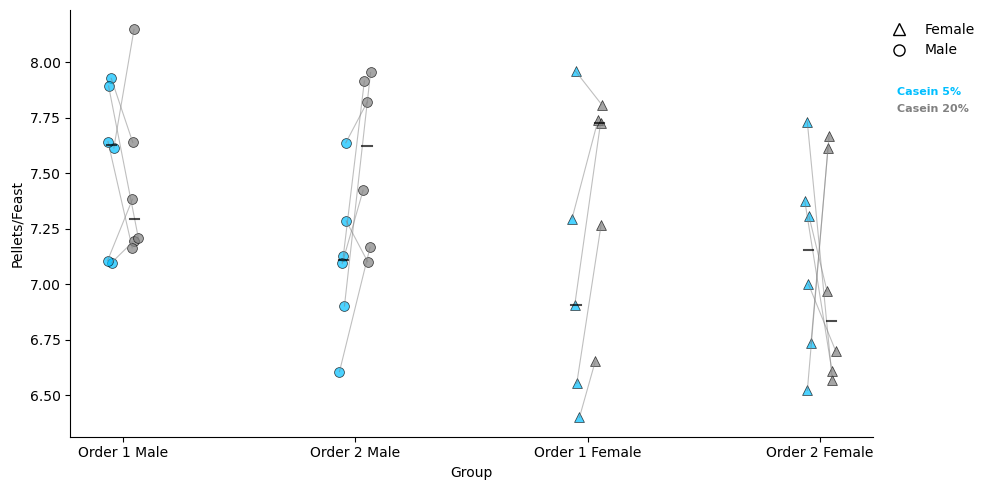

In [72]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Extract Feast frequency data for PR and NR phases, separated by order and sex
nrpr_male_feast_freq = get_data_fields(mice, ["pr_mega_meal_size", "nr_mega_meal_size"], {"order": 1, "sex": "M"})
prnr_male_feast_freq = get_data_fields(mice, ["pr_mega_meal_size", "nr_mega_meal_size"], {"order": 2, "sex": "M"})
nrpr_female_feast_freq = get_data_fields(mice, ["pr_mega_meal_size", "nr_mega_meal_size"], {"order": 1, "sex": "F"})
prnr_female_feast_freq = get_data_fields(mice, ["pr_mega_meal_size", "nr_mega_meal_size"], {"order": 2, "sex": "F"})

# Prepare data for plotting
data = [
    nrpr_male_feast_freq[0], nrpr_male_feast_freq[1], prnr_male_feast_freq[0], prnr_male_feast_freq[1],
    nrpr_female_feast_freq[0], nrpr_female_feast_freq[1], prnr_female_feast_freq[0], prnr_female_feast_freq[1]
]
group_labels = [
    "Order 1 Male (PR)", "Order 1 Male (NR)", "Order 2 Male (PR)", "Order 2 Male (NR)",
    "Order 1 Female (PR)", "Order 1 Female (NR)", "Order 2 Female (PR)", "Order 2 Female (NR)"
]
colors = {"PR": "deepskyblue", "NR": "grey"}
offset = {"PR": -0.05, "NR": 0.05}  # Offset for compact spacing
group_positions = {
    "Order 1 Male": 0, "Order 2 Male": 1,
    "Order 1 Female": 2, "Order 2 Female": 3
}

# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 5))
jitter_strength = 0.02

# Plot data points and connect pairs with lines
for i, label in enumerate(["Order 1 Male", "Order 2 Male", "Order 1 Female", "Order 2 Female"]):
    pr_data = data[i * 2]   # PR data for each group
    nr_data = data[i * 2 + 1]  # NR data for each group

    for j in range(len(pr_data)):
        # Apply jitter to x-positions for PR and NR
        pr_x = group_positions[label] + offset["PR"] + np.random.uniform(-jitter_strength, jitter_strength)
        nr_x = group_positions[label] + offset["NR"] + np.random.uniform(-jitter_strength, jitter_strength)
        
        # Draw line connecting PR and NR for each individual mouse
        ax.plot([pr_x, nr_x], [pr_data[j], nr_data[j]], color='gray', linestyle='-', linewidth=0.8, alpha=0.5)

        # Plot individual data points with gender-specific markers
        marker = '^' if 'Female' in label else 'o'  # Triangles for females, circles for males
        sns.scatterplot(x=[pr_x], y=[pr_data[j]], color=colors["PR"], marker=marker, s=50, alpha=0.7, edgecolor="black")
        sns.scatterplot(x=[nr_x], y=[nr_data[j]], color=colors["NR"], marker=marker, s=50, alpha=0.7, edgecolor="black")

# Add median lines for each group and diet
for group, pos in group_positions.items():
    for diet, diet_color in colors.items():
        relevant_data = data[group_labels.index(f"{group} ({diet})")]
        median_value = np.median(relevant_data)
        x_val = pos + offset[diet]
        ax.plot([x_val - 0.02, x_val + 0.02], [median_value, median_value], color='k', linewidth=1.5, alpha=0.7)

# Customize legend with no frame and no title
custom_lines = [
    Line2D([0], [0], marker='^', color='black', linestyle='', markersize=8, label='Female', fillstyle='none'),
    Line2D([0], [0], marker='o', color='black', linestyle='', markersize=8, label='Male', fillstyle='none')
]
plt.legend(handles=custom_lines, loc="upper left", bbox_to_anchor=(1, 1), frameon=False)


# Add combined colored text for PR and NR next to the legend
plt.text(1.03, 0.8, 'Casein 5%', color='deepskyblue', transform=ax.transAxes, fontsize=8, fontweight='bold')
plt.text(1.03, 0.76, 'Casein 20%', color='grey', transform=ax.transAxes, fontsize=8, fontweight='bold')


# Plot settings
plt.xticks([group_positions["Order 1 Male"], group_positions["Order 2 Male"],
            group_positions["Order 1 Female"], group_positions["Order 2 Female"]],
           ["Order 1 Male", "Order 2 Male", "Order 1 Female", "Order 2 Female"], fontsize=10)
plt.xlabel("Group")
plt.ylabel("Pellets/Feast")
sns.despine()
plt.tight_layout()
plt.show()

# Save the figure if needed
# fig.savefig("feast_frequency_separated_by_sex.pdf")


11 items in output dictionary
12 items in output dictionary


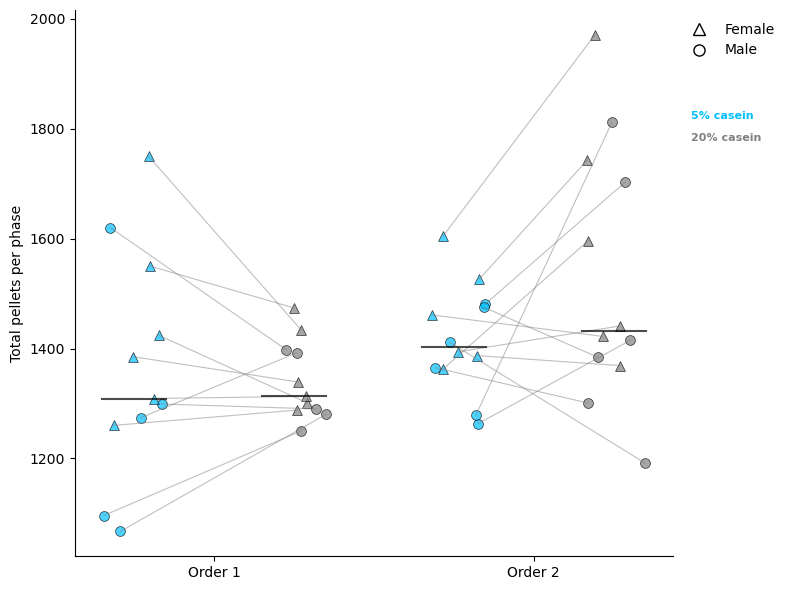

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# Combine male and female data for PR and NR phases within each order
nrpr_order1_data = get_data_fields(mice, ["pr_pellets_per_day", "nr_pellets_per_day"], {"order": 1})
prnr_order2_data = get_data_fields(mice, ["pr_pellets_per_day", "nr_pellets_per_day"], {"order": 2})

# Sum pellets per day for each order and phase
nrpr_order1_pr_pellets = [sum(pellets) for pellets in nrpr_order1_data[0]]
nrpr_order1_nr_pellets = [sum(pellets) for pellets in nrpr_order1_data[1]]
prnr_order2_pr_pellets = [sum(pellets) for pellets in prnr_order2_data[0]]
prnr_order2_nr_pellets = [sum(pellets) for pellets in prnr_order2_data[1]]

# Prepare data for plotting
data = [nrpr_order1_pr_pellets, nrpr_order1_nr_pellets, prnr_order2_pr_pellets, prnr_order2_nr_pellets]
group_labels = ["Order 1 (PR)", "Order 1 (NR)", "Order 2 (PR)", "Order 2 (NR)"]

colors = {"PR": "deepskyblue", "NR": "grey"}
offset = {"PR": -0.05, "NR": 0.05}  # Offset for compact spacing
group_positions = {"Order 1": 0, "Order 2": 0.2}  # Position for minimal gap between groups

# Create a figure and axis
fig, ax = plt.subplots(figsize=(8, 6))
jitter_strength = 0.02

# Plot combined data points with gender-specific markers
for i, label in enumerate(["Order 1", "Order 2"]):
    pr_data = data[i * 2]   # PR data for each order
    nr_data = data[i * 2 + 1]  # NR data for each order

    # Apply jitter to x-positions and assign markers based on sex
    pr_x = [group_positions[label] + offset["PR"] + np.random.uniform(-jitter_strength, jitter_strength) for _ in pr_data]
    nr_x = [group_positions[label] + offset["NR"] + np.random.uniform(-jitter_strength, jitter_strength) for _ in nr_data]
    
    # Draw line connecting PR and NR for each combined data point
    for j in range(len(pr_data)):
        ax.plot([pr_x[j], nr_x[j]], [pr_data[j], nr_data[j]], color='gray', linestyle='-', linewidth=0.8, alpha=0.5)

        # Plot individual data points with markers for gender (combined data)
        marker = '^' if j % 2 == 0 else 'o'  # Alternating marker for visibility in combined data
        sns.scatterplot(x=[pr_x[j]], y=[pr_data[j]], color=colors["PR"], marker=marker, s=50, alpha=0.7, edgecolor="black")
        sns.scatterplot(x=[nr_x[j]], y=[nr_data[j]], color=colors["NR"], marker=marker, s=50, alpha=0.7, edgecolor="black")

# Add median lines for each group and diet
for group, pos in group_positions.items():
    for diet, diet_color in colors.items():
        relevant_data = data[group_labels.index(f"{group} ({diet})")]
        median_value = np.median(relevant_data)
        x_val = pos + offset[diet]
        ax.plot([x_val - 0.02, x_val + 0.02], [median_value, median_value], color='k', linewidth=1.5, alpha=0.7)

# Customize legend with combined markers
custom_lines = [
    Line2D([0], [0], marker='^', color='black', linestyle='', markersize=8, label='Female', fillstyle='none'),
    Line2D([0], [0], marker='o', color='black', linestyle='', markersize=8, label='Male', fillstyle='none')
]
plt.legend(handles=custom_lines, loc="upper left", bbox_to_anchor=(1, 1), frameon=False)

# Add text labels for PR and NR
plt.text(1.03, 0.8, '5% casein', color='deepskyblue', transform=ax.transAxes, fontsize=8, fontweight='bold')
plt.text(1.03, 0.76, '20% casein', color='grey', transform=ax.transAxes, fontsize=8, fontweight='bold')

# Plot settings
plt.xticks([group_positions["Order 1"], group_positions["Order 2"]],
           ["Order 1", "Order 2"], fontsize=10)
plt.xlabel("")
plt.ylabel("Total pellets per phase")
sns.despine()
plt.tight_layout()
plt.show()


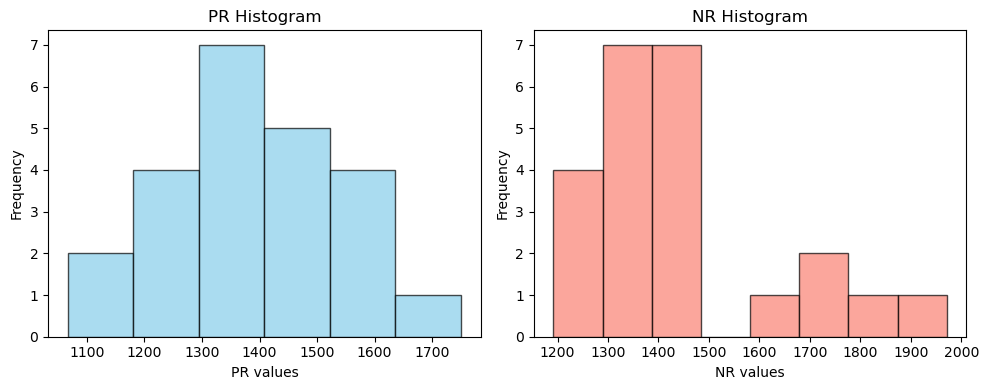

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import probplot

# PR data for all 23 mice (males + females combined)
pr = np.array([
    1362, 1365, 1605, 1481, 1526, 1475, 1260, 1067, 1424, 1274, 1385, 1620,
    1387, 1411, 1461, 1263, 1394, 1279, 1750, 1299, 1550, 1096, 1309
])

# NR data for all 23 mice (males + females combined)
nr = np.array([
    1596, 1301, 1971, 1703, 1743, 1384, 1288, 1280, 1301, 1392, 1339, 1398,
    1369, 1192, 1422, 1415, 1441, 1812, 1433, 1290, 1474, 1250, 1313
])


# Create side-by-side histograms for PR and NR
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# Histogram for PR
axs[0].hist(pr, bins='auto', color='skyblue', edgecolor='black', alpha=0.7)
axs[0].set_title('PR Histogram')
axs[0].set_xlabel('PR values')
axs[0].set_ylabel('Frequency')

# Histogram for NR
axs[1].hist(nr, bins='auto', color='salmon', edgecolor='black', alpha=0.7)
axs[1].set_title('NR Histogram')
axs[1].set_xlabel('NR values')
axs[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


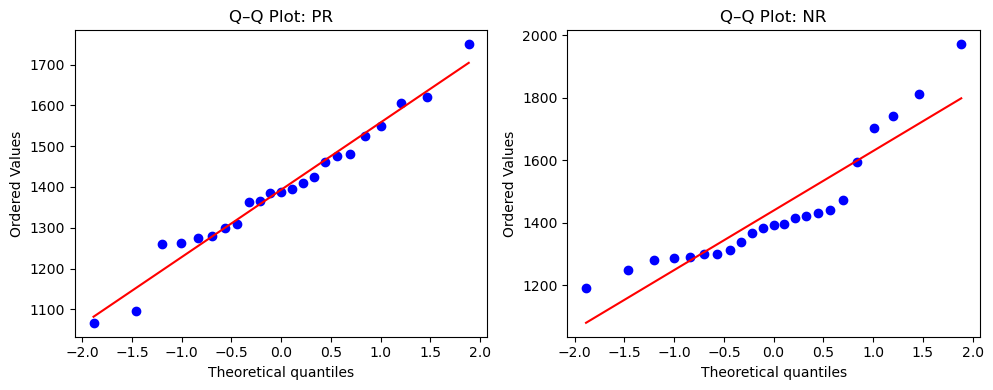

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# Q–Q plot for PR
probplot(pr, dist='norm', plot=axs[0])
axs[0].set_title('Q–Q Plot: PR')

# Q–Q plot for NR
probplot(nr, dist='norm', plot=axs[1])
axs[1].set_title('Q–Q Plot: NR')

plt.tight_layout()
plt.show()


PR (Order=1)  -> W=0.960, p=0.7659
NR (Order=1)  -> W=0.920, p=0.3182
PR (Order=2)  -> W=0.974, p=0.9442
NR (Order=2)  -> W=0.942, p=0.5264


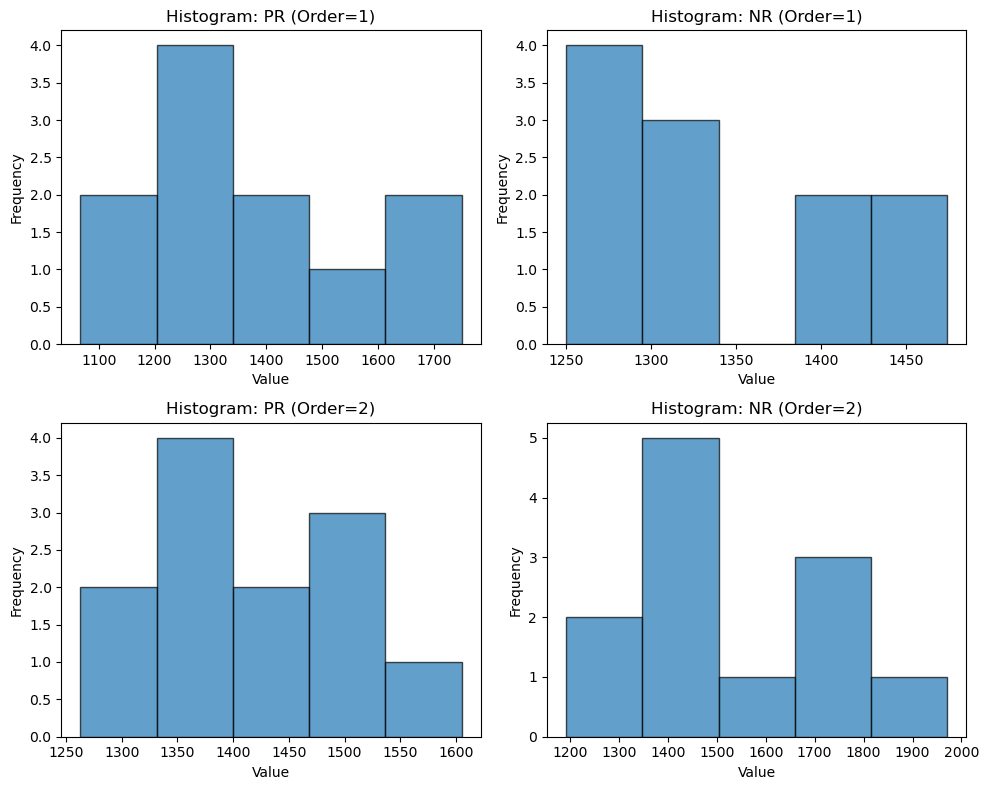

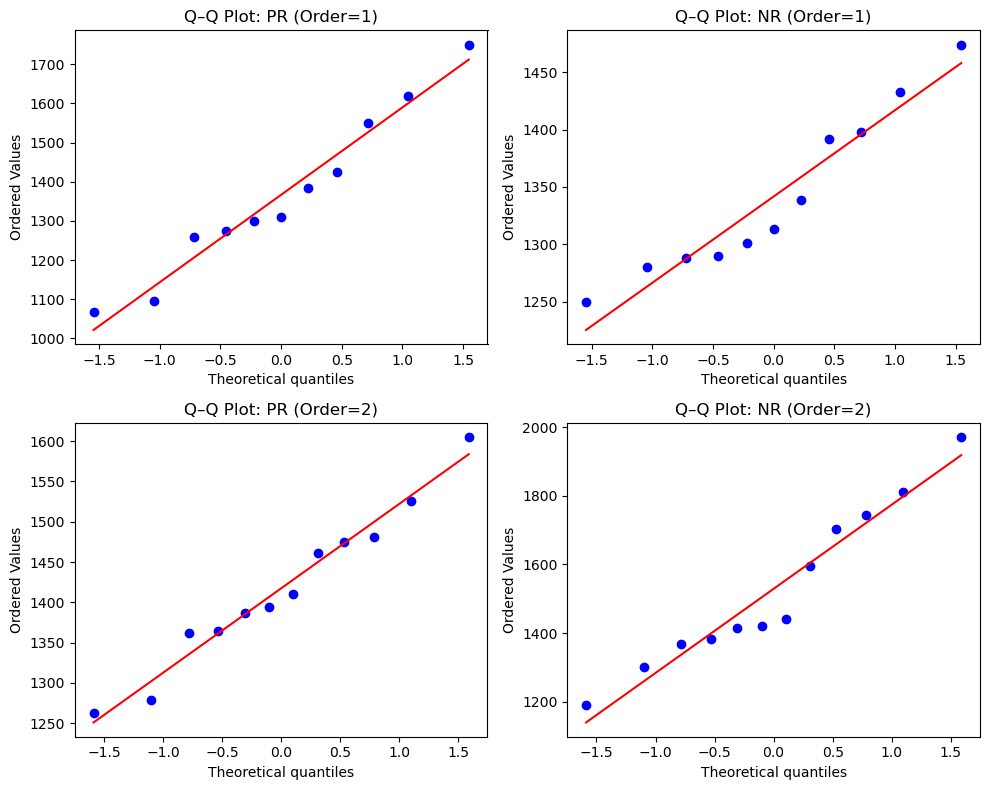

In [8]:
import numpy as np
from scipy.stats import shapiro

pr_order1 = np.array([1260,1067,1424,1274,1385,1620,1750,1299,1550,1096,1309])
nr_order1 = np.array([1288,1280,1301,1392,1339,1398,1433,1290,1474,1250,1313])

pr_order2 = np.array([1362,1365,1605,1481,1526,1475,1387,1411,1461,1263,1394,1279])
nr_order2 = np.array([1596,1301,1971,1703,1743,1384,1369,1192,1422,1415,1441,1812])

data_sets = {
    "PR (Order=1)": pr_order1,
    "NR (Order=1)": nr_order1,
    "PR (Order=2)": pr_order2,
    "NR (Order=2)": nr_order2
}

for name, arr in data_sets.items():
    stat, p = shapiro(arr)
    print(f"{name:13s} -> W={stat:.3f}, p={p:.4f}")



import matplotlib.pyplot as plt
from scipy.stats import probplot

labels = ["PR (Order=1)", "NR (Order=1)", "PR (Order=2)", "NR (Order=2)"]
arrays = [pr_order1, nr_order1, pr_order2, nr_order2]

# --- HISTOGRAMS ---
fig, axs = plt.subplots(2, 2, figsize=(10, 8))
axs = axs.ravel()

for i, (lbl, arr) in enumerate(zip(labels, arrays)):
    axs[i].hist(arr, bins='auto', edgecolor='black', alpha=0.7)
    axs[i].set_title(f"Histogram: {lbl}")
    axs[i].set_xlabel("Value")
    axs[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# --- Q–Q PLOTS ---
fig, axs = plt.subplots(2, 2, figsize=(10, 8))
axs = axs.ravel()

for i, (lbl, arr) in enumerate(zip(labels, arrays)):
    probplot(arr, dist="norm", plot=axs[i])
    axs[i].set_title(f"Q–Q Plot: {lbl}")

plt.tight_layout()
plt.show()


In [9]:
import numpy as np
from scipy.stats import shapiro

pr_order1 = np.array([1260,1067,1424,1274,1385,1620,1750,1299,1550,1096,1309])
nr_order1 = np.array([1288,1280,1301,1392,1339,1398,1433,1290,1474,1250,1313])

pr_order2 = np.array([1362,1365,1605,1481,1526,1475,1387,1411,1461,1263,1394,1279])
nr_order2 = np.array([1596,1301,1971,1703,1743,1384,1369,1192,1422,1415,1441,1812])

data_sets = {
    "PR (Order=1)": pr_order1,
    "NR (Order=1)": nr_order1,
    "PR (Order=2)": pr_order2,
    "NR (Order=2)": nr_order2
}

for name, arr in data_sets.items():
    stat, p = shapiro(arr)
    print(f"{name:13s} -> W={stat:.3f}, p={p:.4f}")


PR (Order=1)  -> W=0.960, p=0.7659
NR (Order=1)  -> W=0.920, p=0.3182
PR (Order=2)  -> W=0.974, p=0.9442
NR (Order=2)  -> W=0.942, p=0.5264


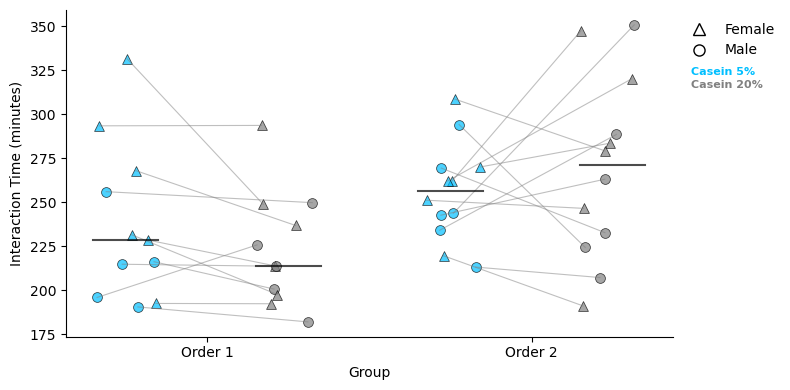

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# Load the dataset
file_path = '../results/FIVE/SCATTER_PLOTS/INTERACTION_PER_PHASE/mice_interaction_times_Updated.csv'  
data = pd.read_csv(file_path)

# Grouping data by order and ignoring the grain phase
nrpr_order1_data = data[data['order'] == 1]
prnr_order2_data = data[data['order'] == 2]

# Separate interaction times for PR and NR phases
nrpr_order1_pr_interaction = nrpr_order1_data['PR'].values
nrpr_order1_nr_interaction = nrpr_order1_data['NR'].values
prnr_order2_pr_interaction = prnr_order2_data['PR'].values
prnr_order2_nr_interaction = prnr_order2_data['NR'].values

# Prepare data for plotting
interaction_data = [
    nrpr_order1_pr_interaction, nrpr_order1_nr_interaction,
    prnr_order2_pr_interaction, prnr_order2_nr_interaction
]
group_labels = ["Order 1 (PR)", "Order 1 (NR)", "Order 2 (PR)", "Order 2 (NR)"]

# Define plot settings
colors = {"PR": "deepskyblue", "NR": "grey"}
offset = {"PR": -0.05, "NR": 0.05}
group_positions = {"Order 1": 0, "Order 2": 0.2}

# Create a figure and axis
fig, ax = plt.subplots(figsize=(8, 4))
jitter_strength = 0.02

# Plot combined data points with gender-specific markers
for i, label in enumerate(["Order 1", "Order 2"]):
    pr_data = interaction_data[i * 2]   # PR data for each order
    nr_data = interaction_data[i * 2 + 1]  # NR data for each order

    # Apply jitter to x-positions and assign markers based on sex
    pr_x = [group_positions[label] + offset["PR"] + np.random.uniform(-jitter_strength, jitter_strength) for _ in pr_data]
    nr_x = [group_positions[label] + offset["NR"] + np.random.uniform(-jitter_strength, jitter_strength) for _ in nr_data]
    
    # Draw line connecting PR and NR for each combined data point
    for j in range(len(pr_data)):
        ax.plot([pr_x[j], nr_x[j]], [pr_data[j], nr_data[j]], color='gray', linestyle='-', linewidth=0.8, alpha=0.5)

        # Plot individual data points with markers for combined data
        marker = '^' if j % 2 == 0 else 'o'  # Alternate marker for visualization within combined data
        sns.scatterplot(x=[pr_x[j]], y=[pr_data[j]], color=colors["PR"], marker=marker, s=50, alpha=0.7, edgecolor="black")
        sns.scatterplot(x=[nr_x[j]], y=[nr_data[j]], color=colors["NR"], marker=marker, s=50, alpha=0.7, edgecolor="black")

# Add median lines for each group and diet
for group, pos in group_positions.items():
    for diet, diet_color in colors.items():
        relevant_data = interaction_data[group_labels.index(f"{group} ({diet})")]
        median_value = np.median(relevant_data)
        x_val = pos + offset[diet]
        ax.plot([x_val - 0.02, x_val + 0.02], [median_value, median_value], color='k', linewidth=1.5, alpha=0.7)

# Customize legend with combined markers for gender
custom_lines = [
    Line2D([0], [0], marker='^', color='black', linestyle='', markersize=8, label='Female', fillstyle='none'),
    Line2D([0], [0], marker='o', color='black', linestyle='', markersize=8, label='Male', fillstyle='none')
]
plt.legend(handles=custom_lines, loc="upper left", bbox_to_anchor=(1, 1), frameon=False)

# Add text labels for PR and NR phases
plt.text(1.03, 0.8, 'Casein 5%', color='deepskyblue', transform=ax.transAxes, fontsize=8, fontweight='bold')
plt.text(1.03, 0.76, 'Casein 20%', color='grey', transform=ax.transAxes, fontsize=8, fontweight='bold')

# Plot settings
plt.xticks([group_positions["Order 1"], group_positions["Order 2"]],
           ["Order 1", "Order 2"], fontsize=10)
plt.xlabel("Group")
plt.ylabel("Interaction Time (minutes)")
sns.despine()
plt.tight_layout()
plt.show()


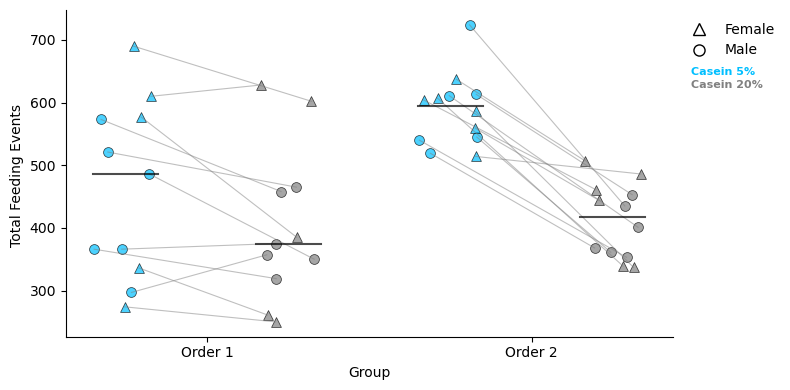

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# Load the dataset
file_path = '../results/FIVE/SCATTER_PLOTS/SUM_OF_FEEDING_COMPONENTS/TOTAL_FEEDING_EVENTS.csv'
data = pd.read_csv(file_path)

# Separate data by order
nrpr_order1_data = data[data['Order'] == 1]
prnr_order2_data = data[data['Order'] == 2]

# Extract feeding data for plotting
nrpr_order1_pr = nrpr_order1_data['Total PR Parameters'].values
nrpr_order1_nr = nrpr_order1_data['Total NR Parameters'].values
prnr_order2_pr = prnr_order2_data['Total PR Parameters'].values
prnr_order2_nr = prnr_order2_data['Total NR Parameters'].values

# Prepare data for plotting
feeding_totals = [
    nrpr_order1_pr, nrpr_order1_nr,
    prnr_order2_pr, prnr_order2_nr
]
group_labels = ["Order 1 (PR)", "Order 1 (NR)", "Order 2 (PR)", "Order 2 (NR)"]
colors = {"PR": "deepskyblue", "NR": "grey"}
offset = {"PR": -0.05, "NR": 0.05}
group_positions = {"Order 1": 0, "Order 2": 0.2}
jitter_strength = 0.02

# Create the plot
fig, ax = plt.subplots(figsize=(8, 4))

# Plot data points with markers for sex and diet phase
for i, label in enumerate(["Order 1", "Order 2"]):
    pr_data = feeding_totals[i * 2]   # PR data for each order
    nr_data = feeding_totals[i * 2 + 1]  # NR data for each order
    sex_data_pr = nrpr_order1_data['Sex'].values if label == "Order 1" else prnr_order2_data['Sex'].values

    # Apply jitter to x-positions and assign markers based on sex
    pr_x = [group_positions[label] + offset["PR"] + np.random.uniform(-jitter_strength, jitter_strength) for _ in pr_data]
    nr_x = [group_positions[label] + offset["NR"] + np.random.uniform(-jitter_strength, jitter_strength) for _ in nr_data]

    # Draw line connecting PR and NR for each combined data point
    for j in range(len(pr_data)):
        ax.plot([pr_x[j], nr_x[j]], [pr_data[j], nr_data[j]], color='gray', linestyle='-', linewidth=0.8, alpha=0.5)

        # Plot individual data points with markers based on sex
        sex_marker = '^' if sex_data_pr[j] == 'F' else 'o'  # Triangle for females, circle for males
        sns.scatterplot(x=[pr_x[j]], y=[pr_data[j]], color=colors["PR"], marker=sex_marker, s=50, alpha=0.7, edgecolor="black")
        sns.scatterplot(x=[nr_x[j]], y=[nr_data[j]], color=colors["NR"], marker=sex_marker, s=50, alpha=0.7, edgecolor="black")

# Add median lines for each group and diet
for group, pos in group_positions.items():
    for diet, diet_color in colors.items():
        relevant_data = feeding_totals[group_labels.index(f"{group} ({diet})")]
        median_value = np.median(relevant_data)
        x_val = pos + offset[diet]
        ax.plot([x_val - 0.02, x_val + 0.02], [median_value, median_value], color='k', linewidth=1.5, alpha=0.7)

# Customize legend with markers for male and female
custom_lines = [
    Line2D([0], [0], marker='^', color='black', linestyle='', markersize=8, label='Female', fillstyle='none'),
    Line2D([0], [0], marker='o', color='black', linestyle='', markersize=8, label='Male', fillstyle='none')
]
plt.legend(handles=custom_lines, loc="upper left", bbox_to_anchor=(1, 1), frameon=False)

# Add text labels for PR and NR phases
plt.text(1.03, 0.8, 'Casein 5%', color='deepskyblue', transform=ax.transAxes, fontsize=8, fontweight='bold')
plt.text(1.03, 0.76, 'Casein 20%', color='grey', transform=ax.transAxes, fontsize=8, fontweight='bold')

# Plot settings
plt.xticks([group_positions["Order 1"], group_positions["Order 2"]],
           ["Order 1", "Order 2"], fontsize=10)
plt.xlabel("Group")
plt.ylabel("Total Feeding Events ")
sns.despine()
plt.tight_layout()
plt.show()


# Below , plotting preference of NR pellets in two orders, not going to use it in the paper

11 items in output dictionary
12 items in output dictionary


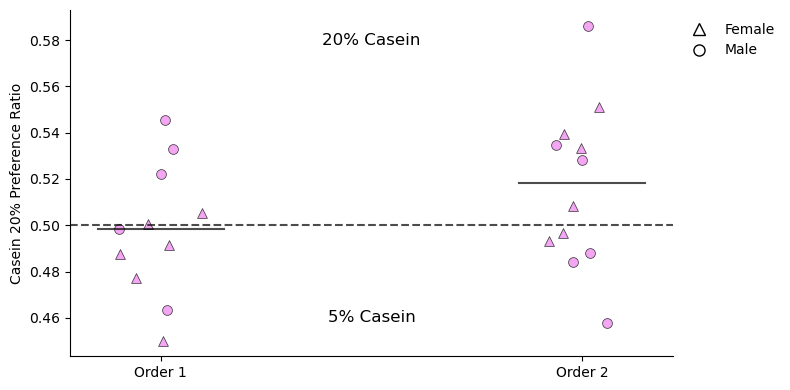

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# Combine male and female data for PR and NR phases within each order
nrpr_order1_data = get_data_fields(mice, ["pr_pellets_per_day", "nr_pellets_per_day"], {"order": 1})
prnr_order2_data = get_data_fields(mice, ["pr_pellets_per_day", "nr_pellets_per_day"], {"order": 2})

# Sum pellets per day for each order and phase
nrpr_order1_pr_pellets = [sum(pellets) for pellets in nrpr_order1_data[0]]
nrpr_order1_nr_pellets = [sum(pellets) for pellets in nrpr_order1_data[1]]
prnr_order2_pr_pellets = [sum(pellets) for pellets in prnr_order2_data[0]]
prnr_order2_nr_pellets = [sum(pellets) for pellets in prnr_order2_data[1]]

# Calculate preference ratios for NR (Total NR / (Total NR + Total PR))
nrpr_order1_ratio = [
    nr / (nr + pr) if (nr + pr) > 0 else 0 for nr, pr in zip(nrpr_order1_nr_pellets, nrpr_order1_pr_pellets)
]
prnr_order2_ratio = [
    nr / (nr + pr) if (nr + pr) > 0 else 0 for nr, pr in zip(prnr_order2_nr_pellets, prnr_order2_pr_pellets)
]

# Prepare data for plotting
preference_ratios = [nrpr_order1_ratio, prnr_order2_ratio]
group_labels = ["Order 1", "Order 2"]
colors = {"NR": "violet", "PR": "grey"}
group_positions = {"Order 1": 0, "Order 2": 0.2}
jitter_strength = 0.02

# Create the plot
fig, ax = plt.subplots(figsize=(8, 4))

# Plot NR preference ratios with markers for sex
for i, label in enumerate(group_labels):
    ratios = preference_ratios[i]
    # Apply jitter to x-positions
    x_positions = [group_positions[label] + np.random.uniform(-jitter_strength, jitter_strength) for _ in ratios]

    # Draw each data point with alternating markers for males and females
    for j, ratio in enumerate(ratios):
        marker = '^' if j % 2 == 0 else 'o'  # Triangle for females, circle for males
        sns.scatterplot(x=[x_positions[j]], y=[ratio], color=colors["NR"], marker=marker, s=50, alpha=0.7, edgecolor="black")

# Add median lines for each order's NR preference
for group, pos in group_positions.items():
    relevant_data = preference_ratios[group_labels.index(group)]
    median_value = np.median(relevant_data)
    ax.plot([pos - 0.03, pos + 0.03], [median_value, median_value], color='k', linewidth=1.5, alpha=0.7)

# Customize legend for male and female markers
custom_lines = [
    Line2D([0], [0], marker='^', color='black', linestyle='', markersize=8, label='Female', fillstyle='none'),
    Line2D([0], [0], marker='o', color='black', linestyle='', markersize=8, label='Male', fillstyle='none')
]
plt.legend(handles=custom_lines, loc="upper left", bbox_to_anchor=(1, 1), frameon=False)

# Reference line at y=0.5 indicating no preference
plt.axhline(0.5, ls='--', color='black', linewidth=1.5, alpha=0.7)


# Add annotations for the y-axis
plt.text(0.5, 0.9, "20% Casein", fontsize=12, ha='center', transform=plt.gca().transAxes, color='black')
plt.text(0.5, 0.1, "5% Casein", fontsize=12, ha='center', transform=plt.gca().transAxes, color='black')

# Plot settings
plt.xticks([group_positions["Order 1"], group_positions["Order 2"]], ["Order 1", "Order 2"], fontsize=10)
plt.xlabel("")
plt.ylabel("Casein 20% Preference Ratio")
sns.despine()
plt.tight_layout()
plt.show()


In [49]:
import pandas as pd


mouse_ids_order1 = list(mice.keys())[:len(nrpr_order1_pr_pellets)]
mouse_ids_order2 = list(mice.keys())[len(nrpr_order1_pr_pellets):]

# Create data for Order 1 with NR preference ratios
order1_data = pd.DataFrame({
    "mouse_id": mouse_ids_order1,
    "sex": ["F" if i % 2 == 0 else "M" for i in range(len(mouse_ids_order1))],
    "order": [1] * len(mouse_ids_order1),
    "preference_ratio": nrpr_order1_ratio
})

# Create data for Order 2 with NR preference ratios
order2_data = pd.DataFrame({
    "mouse_id": mouse_ids_order2,
    "sex": ["F" if i % 2 == 0 else "M" for i in range(len(mouse_ids_order2))],
    "order": [2] * len(mouse_ids_order2),
    "preference_ratio": prnr_order2_ratio
})

# Combine Order 1 and Order 2 data
combined_data = pd.concat([order1_data, order2_data], ignore_index=True)

# Save to CSV
output_file_path = "..//results//preference_ratios.csv"
combined_data.to_csv(output_file_path, index=False)

print(f"Data saved to {output_file_path}")


Data saved to ..//results//preference_ratios.csv


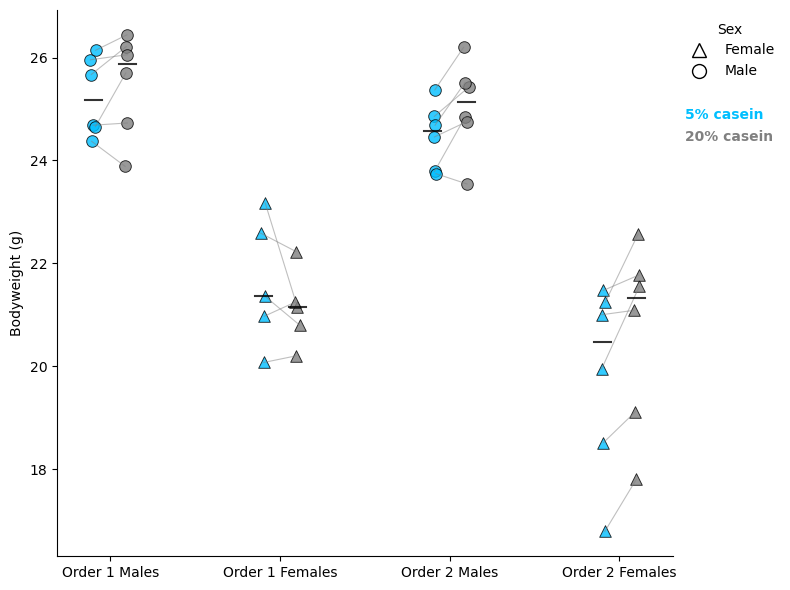

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.lines import Line2D

# Load your data
file_path = '../results/FIVE/SCATTER_PLOTS/BODYWEIGHT/AV_BODYWEIGHT_PER_PHASE.csv'
data = pd.read_csv(file_path)

# Define plot settings
colors = {"PR": "deepskyblue", "NR": "grey"}
markers = {"M": "o", "F": "^"}
offsets = {"PR": -0.1, "NR": 0.1}
group_positions = {
    "Order 1 M": 0, "Order 1 F": 1,
    "Order 2 M": 2, "Order 2 F": 3
}
jitter_strength = 0.02

# Create the plot
fig, ax = plt.subplots(figsize=(8, 6))

# Plot each group separately
for (order, sex), group_data in data.groupby(['Order', 'Sex']):
    group_label = f"Order {order} {sex}"
    pr_x = [group_positions[group_label] + offsets["PR"] + np.random.uniform(-jitter_strength, jitter_strength) for _ in group_data['PR']]
    nr_x = [group_positions[group_label] + offsets["NR"] + np.random.uniform(-jitter_strength, jitter_strength) for _ in group_data['NR']]
    
    # Draw connecting lines for PR and NR values
    for i in range(len(group_data)):
        ax.plot([pr_x[i], nr_x[i]], [group_data['PR'].iloc[i], group_data['NR'].iloc[i]], 
                color='gray', linestyle='-', linewidth=0.8, alpha=0.5)
        
    # Scatterplot for PR values
    sns.scatterplot(x=pr_x, y=group_data['PR'], color=colors["PR"], 
                    marker=markers[sex], s=70, alpha=0.8, edgecolor="black", label=None)
    
    # Scatterplot for NR values
    sns.scatterplot(x=nr_x, y=group_data['NR'], color=colors["NR"], 
                    marker=markers[sex], s=70, alpha=0.8, edgecolor="black", label=None)

# Add median lines for each group
for (order, sex), group_data in data.groupby(['Order', 'Sex']):
    group_label = f"Order {order} {sex}"
    for phase in ["PR", "NR"]:
        median_value = group_data[phase].median()
        x_val = group_positions[group_label] + offsets[phase]
        ax.plot([x_val - 0.05, x_val + 0.05], [median_value, median_value], color='black', linewidth=1.5, alpha=0.8)

# Customise plot appearance
ax.set_xticks([group_positions["Order 1 M"], group_positions["Order 1 F"], 
               group_positions["Order 2 M"], group_positions["Order 2 F"]])
ax.set_xticklabels(["Order 1 Males", "Order 1 Females", "Order 2 Males", "Order 2 Females"])
ax.set_xlabel("")
ax.set_ylabel("Bodyweight (g)")
sns.despine()

# Add legend for sex markers
custom_lines = [
    Line2D([0], [0], marker='^', color='black', linestyle='', markersize=10, label='Female', fillstyle='none'),
    Line2D([0], [0], marker='o', color='black', linestyle='', markersize=10, label='Male', fillstyle='none')
]
plt.legend(handles=custom_lines, title="Sex", loc="upper left", bbox_to_anchor=(1, 1), frameon=False)

# Add text labels for phases
plt.text(1.02, 0.8, '5% casein', color='deepskyblue', transform=ax.transAxes, fontsize=10, fontweight='bold')
plt.text(1.02, 0.76, '20% casein', color='grey', transform=ax.transAxes, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()
